# 02 — Data Cleaning

## The drivers of economic growth in Europe: evidence from productivity and investment

This notebook converts the broad collected panel into two analysis-ready datasets. The goal is not to force every variable into one sample, but to make transparent decisions about **time coverage, missing data, extreme observations, and panel balance**.

- The **core sample** supports the main productivity–investment analysis.
- The **extended sample** retains education expenditure for supplementary descriptive work.

In [65]:
# Import the required libraries
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")

# Plot settings
sns.set_theme(style="whitegrid")

## 1. Data import and initial inspection

We import the combined panel created during data collection and inspect its structure before making any changes.

In [ ]:
# Locate the project folder.
project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent

processed_dir = project_dir / "data" / "processed"
input_file = processed_dir / "europe_panel_collected.csv"

if not input_file.exists():
    raise FileNotFoundError(
        "Run 01_data_collection.ipynb first. "
        f"Expected file: {input_file}"
    )

panel = pd.read_csv(input_file)

print("Dataset dimensions:", panel.shape)
display(panel.head())

### Structural validation

We verify the panel dimensions, column names, data types, country and year coverage, and the uniqueness of each country-year observation.

In [67]:
# Display column names and data types
print("Columns:")
print(panel.columns.tolist())

print("\nData types:")
print(panel.dtypes)

# Check the geographical and temporal dimensions
print("\nNumber of countries:", panel["Country Code"].nunique())
print("First year:", panel["Year"].min())
print("Last year:", panel["Year"].max())
print("Number of years:", panel["Year"].nunique())

# Check for duplicate country-year observations
duplicate_country_years = panel.duplicated(
    subset=["Country Code", "Year"]
).sum()

print("\nDuplicate country-year observations:", duplicate_country_years)

# Verify whether the panel is structurally balanced
observations_per_country = panel.groupby("Country Code")["Year"].nunique()

print(
    "Years per country:",
    observations_per_country.min(),
    "-",
    observations_per_country.max()
)

Columns:
['Country Name', 'Country Code', 'Year', 'GDP Growth', 'Investment', 'Education Expenditure', 'Productivity Growth']

Data types:
Country Name                 str
Country Code                 str
Year                       int64
GDP Growth               float64
Investment               float64
Education Expenditure    float64
Productivity Growth      float64
dtype: object

Number of countries: 46
First year: 1960
Last year: 2018
Number of years: 59

Duplicate country-year observations: 0
Years per country: 59 - 59


## 2. Missing-value analysis

A structurally balanced panel can still contain missing economic values. We first measure missingness for each variable and then examine how coverage changes over time. This evidence determines the analysis period and sample definition.

In [68]:
# Variables used in the economic analysis
analysis_variables = [
    "GDP Growth",
    "Investment",
    "Education Expenditure",
    "Productivity Growth"
]

# Calculate missing-value statistics
missing_summary = pd.DataFrame({
    "Missing Values": panel[analysis_variables].isna().sum(),
    "Missing Percentage": (
        panel[analysis_variables].isna().mean() * 100
    ),
    "Available Values": panel[analysis_variables].notna().sum(),
    "Available Percentage": (
        panel[analysis_variables].notna().mean() * 100
    )
})

missing_summary = missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

display(missing_summary.round(2))

,Missing Values,Missing Percentage,Available Values,Available Percentage
Education Expenditure,1516,55.860,1198,44.140
Productivity Growth,1258,46.350,1456,53.650
Investment,1078,39.720,1636,60.280
GDP Growth,753,27.750,1961,72.250


In [69]:
# Count available variables in each country-year observation
panel["Available Variables"] = (
    panel[analysis_variables]
    .notna()
    .sum(axis=1)
)

print("Observations with all four variables available:")
print((panel["Available Variables"] == 4).sum())

print("\nObservations with no variables available:")
print((panel["Available Variables"] == 0).sum())

print("\nDistribution of available variables per row:")
display(
    panel["Available Variables"]
    .value_counts()
    .sort_index()
    .rename_axis("Number of available variables")
    .to_frame("Country-year observations")
)

Observations with all four variables available:
978

Observations with no variables available:
684

Distribution of available variables per row:


,Country-year observations
Number of available variables,
0,684
1,309
2,199
3,544
4,978


### Missing values over time

We examine how data availability changes over time. This helps identify a period with sufficient coverage for the four-variable empirical analysis.

In [70]:
# Calculate annual data availability
yearly_coverage = (
    panel.groupby("Year")[analysis_variables]
    .agg(lambda column: column.notna().sum())
)

# Rename columns to indicate that the values are country counts
yearly_coverage.columns = [
    "GDP Countries",
    "Investment Countries",
    "Education Countries",
    "Productivity Countries"
]

# Count countries with all four variables available in each year
yearly_coverage["Complete Countries"] = (
    panel.dropna(subset=analysis_variables)
    .groupby("Year")
    .size()
    .reindex(yearly_coverage.index, fill_value=0)
)

display(yearly_coverage)

,GDP Countries,Investment Countries,Education Countries,Productivity Countries,Complete Countries
Year,,,,,
1960,0,4,0,0,0
1961,20,4,0,0,0
1962,20,4,0,0,0
1963,20,4,0,0,0
1964,20,4,0,0,0
1965,20,4,0,0,0
1966,20,5,0,0,0
1967,20,5,0,0,0
1968,20,5,0,0,0


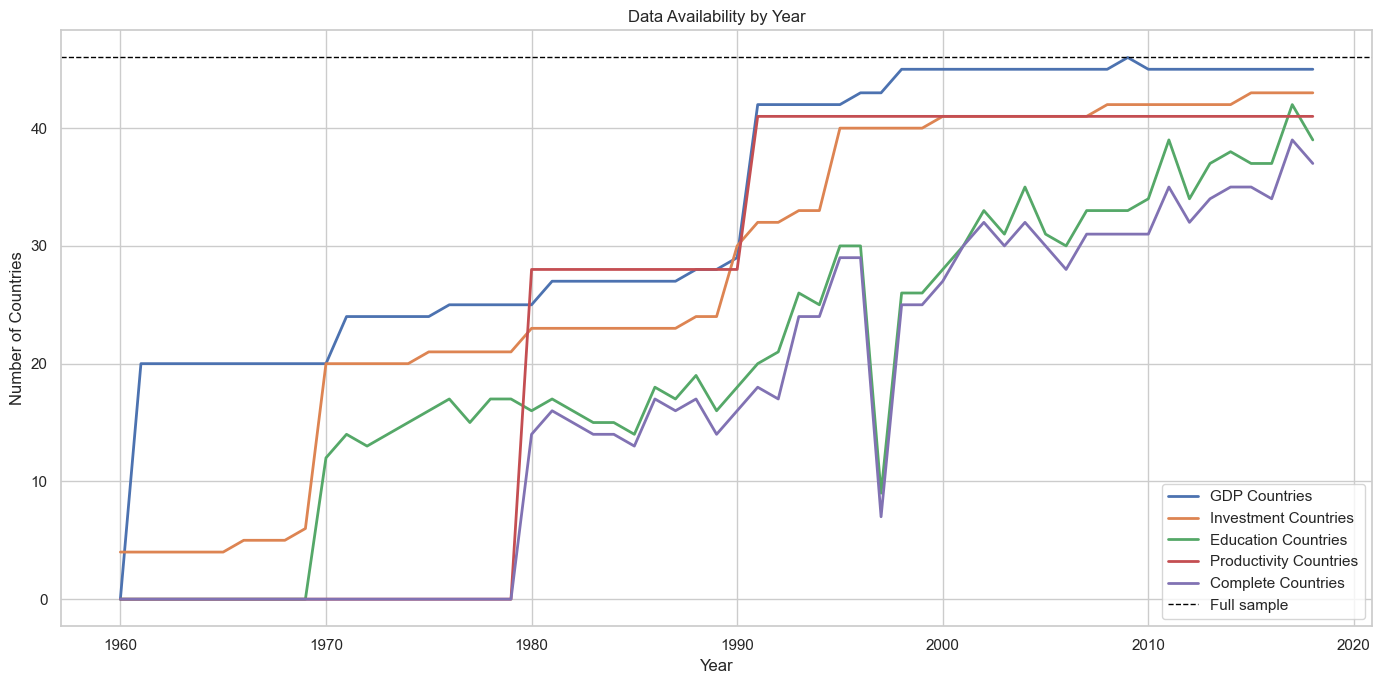

In [71]:
# Plot the number of countries with available observations by year
plt.figure(figsize=(14, 7))

for column in yearly_coverage.columns:
    plt.plot(
        yearly_coverage.index,
        yearly_coverage[column],
        label=column,
        linewidth=2
    )

plt.axhline(
    y=46,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Full sample"
)

plt.title("Data Availability by Year")
plt.xlabel("Year")
plt.ylabel("Number of Countries")
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
# Years with the greatest four-variable coverage
display(
    yearly_coverage[["Complete Countries"]]
    .sort_values("Complete Countries", ascending=False)
    .head(20)
)

# Complete-case coverage by decade
coverage_by_row = panel.assign(
    Decade=(panel["Year"] // 10) * 10,
    Complete=panel[analysis_variables].notna().all(axis=1)
)

decade_coverage = (
    coverage_by_row
    .groupby("Decade")
    .agg(
        Potential_Observations=("Year", "size"),
        Complete_Observations=("Complete", "sum")
    )
)

decade_coverage["Complete_Percentage"] = (
    decade_coverage["Complete_Observations"]
    / decade_coverage["Potential_Observations"]
    * 100
)

display(decade_coverage.round(2))

,Complete Countries
Year,
2017,39
2018,37
2015,35
2014,35
2011,35
2016,34
2013,34
2004,32
2012,32


,Potential Observations,Complete Observations,Complete Percentage
Decade,,,
1960,460,0,0.000
1970,460,0,0.000
1980,460,150,32.610
1990,460,214,46.520
2000,460,302,65.650
2010,414,312,75.360


## 3. Analysis period: 2000–2018

The final period balances recency, coverage, and comparability. Earlier decades contain substantially fewer complete observations, while the productivity source ends in 2018. Using 2000–2018 produces **19 annual observations per country** in the balanced core sample.

In [73]:
# Define the selected analysis period
analysis_start_year = 2000
analysis_end_year = 2018

# Restrict the panel to the selected period
panel_period = panel[
    panel["Year"].between(
        analysis_start_year,
        analysis_end_year
    )
].copy()

# Recalculate the number of available variables
panel_period["Available Variables"] = (
    panel_period[analysis_variables]
    .notna()
    .sum(axis=1)
)

complete_observations = (
    panel_period[analysis_variables]
    .notna()
    .all(axis=1)
    .sum()
)

print("Selected period:", analysis_start_year, "-", analysis_end_year)
print("Number of countries:", panel_period["Country Code"].nunique())
print("Potential observations:", len(panel_period))
print("Complete observations:", complete_observations)

print(
    "Complete percentage:",
    round(complete_observations / len(panel_period) * 100, 2),
    "%"
)

Selected period: 2000 - 2018
Number of countries: 46
Potential observations: 874
Complete observations: 614
Complete percentage: 70.25 %


In [74]:
# Calculate country-level coverage in the selected period
country_coverage = (
    panel_period
    .groupby(["Country Code", "Country Name"])
    .agg(
        Potential_Observations=("Year", "size"),
        GDP_Available=("GDP Growth", "count"),
        Investment_Available=("Investment", "count"),
        Education_Available=("Education Expenditure", "count"),
        Productivity_Available=("Productivity Growth", "count")
    )
    .reset_index()
)

# Count complete observations for each country
country_complete = (
    panel_period
    .assign(
        Complete=panel_period[analysis_variables]
        .notna()
        .all(axis=1)
    )
    .groupby(["Country Code", "Country Name"])["Complete"]
    .sum()
    .reset_index(name="Complete_Observations")
)

country_coverage = country_coverage.merge(
    country_complete,
    on=["Country Code", "Country Name"],
    how="left"
)

country_coverage["Complete_Percentage"] = (
    country_coverage["Complete_Observations"]
    / country_coverage["Potential_Observations"]
    * 100
)

display(
    country_coverage
    .sort_values(
        ["Complete_Observations", "Country Name"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
    .round(2)
)

,Country Code,Country Name,Potential_Observations,GDP_Available,Investment_Available,Education_Available,Productivity_Available,Complete_Observations,Complete_Percentage
0,AND,Andorra,19,19,0,16,0,0,0.000
1,XKX,Kosovo,19,10,11,0,0,0,0.000
2,LIE,Liechtenstein,19,10,0,6,0,0,0.000
3,MCO,Monaco,19,19,0,10,0,0,0.000
4,MNE,Montenegro,19,19,19,0,19,0,0.000
5,SMR,San Marino,19,19,4,8,0,0,0.000
6,MKD,North Macedonia,19,19,19,1,19,1,5.260
7,FRA,France,19,19,19,2,19,2,10.530
8,BIH,Bosnia and Herzegovina,19,19,19,5,19,5,26.320
9,LUX,Luxembourg,19,19,19,6,19,6,31.580


## 4. Analytical samples

Education expenditure is the main source of missingness, so it is not allowed to reduce the main productivity–investment sample.

| Sample | Required variables | Purpose |
|---|---|---|
| Core | GDP growth, productivity growth, investment | Main EDA and panel regressions |
| Extended | Core variables plus education expenditure | Supplementary education analysis |

In [75]:
# Variables required for the main specification
core_variables = [
    "GDP Growth",
    "Investment",
    "Productivity Growth"
]

# Create the core sample
core_sample = (
    panel_period
    .dropna(subset=core_variables)
    .drop(columns=["Available Variables"], errors="ignore")
    .sort_values(["Country Name", "Year"])
    .reset_index(drop=True)
)

# Create the extended sample including education
extended_sample = (
    panel_period
    .dropna(subset=analysis_variables)
    .drop(columns=["Available Variables"], errors="ignore")
    .sort_values(["Country Name", "Year"])
    .reset_index(drop=True)
)

print("CORE SAMPLE")
print("Countries:", core_sample["Country Code"].nunique())
print("Observations:", len(core_sample))
print(
    "Period:",
    core_sample["Year"].min(),
    "-",
    core_sample["Year"].max()
)

print("\nEXTENDED SAMPLE")
print("Countries:", extended_sample["Country Code"].nunique())
print("Observations:", len(extended_sample))
print(
    "Period:",
    extended_sample["Year"].min(),
    "-",
    extended_sample["Year"].max()
)

CORE SAMPLE
Countries: 41
Observations: 779
Period: 2000 - 2018

EXTENDED SAMPLE
Countries: 40
Observations: 614
Period: 2000 - 2018


In [76]:
# Check whether the core panel is balanced
core_country_years = (
    core_sample
    .groupby(["Country Code", "Country Name"])["Year"]
    .nunique()
    .sort_values()
)

print(
    "Years per country in the core sample:",
    core_country_years.min(),
    "-",
    core_country_years.max()
)

print(
    "Missing values in core variables:",
    core_sample[core_variables].isna().sum().sum()
)

# Countries excluded from the core sample
excluded_core_countries = (
    panel_period.loc[
        ~panel_period["Country Code"].isin(
            core_sample["Country Code"].unique()
        ),
        ["Country Code", "Country Name"]
    ]
    .drop_duplicates()
    .sort_values("Country Name")
    .reset_index(drop=True)
)

display(excluded_core_countries)

Years per country in the core sample: 19 - 19
Missing values in core variables: 0


,Country Code,Country Name
0,AND,Andorra
1,XKX,Kosovo
2,LIE,Liechtenstein
3,MCO,Monaco
4,SMR,San Marino


### Sample result

The core sample is a **balanced panel of 41 countries × 19 years = 779 observations**. Andorra, Kosovo, Liechtenstein, Monaco, and San Marino are excluded because the productivity dataset does not provide the required series. The education sample contains 614 complete observations across 40 countries and is unbalanced, so it is used cautiously.

## 5. Value validation and potential outliers

Impossible percentage values and infinite values are checked directly. The IQR rule then flags unusual observations for investigation. It is a diagnostic—not an automatic deletion rule—because crises and rapid recoveries can produce valid macroeconomic extremes.

In [77]:
# Produce descriptive statistics for the core sample
core_descriptive_statistics = (
    core_sample[core_variables]
    .describe()
    .T
)

core_descriptive_statistics["Median"] = (
    core_sample[core_variables].median()
)

display(core_descriptive_statistics.round(3))

,count,mean,std,min,25%,50%,75%,max,Median
GDP Growth,779.000,2.823,3.688,-16.040,1.228,2.824,4.725,24.624,2.824
Investment,779.000,23.660,5.052,9.064,20.387,22.857,26.337,43.666,22.857
Productivity Growth,779.000,2.095,3.289,-11.300,0.255,1.600,3.560,20.930,1.600


In [79]:
# Check for positive or negative infinity
print(
    "Infinite values in the core sample:",
    np.isinf(core_sample[core_variables].to_numpy()).sum()
)

print(
    "Infinite values in the extended sample:",
    np.isinf(
        extended_sample[analysis_variables].to_numpy()
    ).sum()
)

# Investment and education are percentages of GDP
invalid_investment = core_sample[
    (core_sample["Investment"] < 0) |
    (core_sample["Investment"] > 100)
]

invalid_education = extended_sample[
    (extended_sample["Education Expenditure"] < 0) |
    (extended_sample["Education Expenditure"] > 100)
]

print("\nInvalid investment observations:", len(invalid_investment))
print("Invalid education observations:", len(invalid_education))

display(invalid_investment)
display(invalid_education)

Infinite values in the core sample: 0
Infinite values in the extended sample: 0

Invalid investment observations: 0
Invalid education observations: 0


,Country Name,Country Code,Year,GDP Growth,Investment,Education Expenditure,Productivity Growth


,Country Name,Country Code,Year,GDP Growth,Investment,Education Expenditure,Productivity Growth


In [80]:
def identify_iqr_outliers(data, variables):
    """
    Identify observations outside 1.5 times the interquartile range.
    """
    results = []

    for variable in variables:
        q1 = data[variable].quantile(0.25)
        q3 = data[variable].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        variable_outliers = data[
            (data[variable] < lower_bound) |
            (data[variable] > upper_bound)
        ][
            [
                "Country Code",
                "Country Name",
                "Year",
                variable
            ]
        ].copy()

        variable_outliers["Variable"] = variable
        variable_outliers["Lower Bound"] = lower_bound
        variable_outliers["Upper Bound"] = upper_bound

        variable_outliers = variable_outliers.rename(
            columns={variable: "Value"}
        )

        results.append(variable_outliers)

    return pd.concat(results, ignore_index=True)


# Identify potential outliers in the core variables
core_outliers = identify_iqr_outliers(
    core_sample,
    core_variables
)

print("Potential core-sample outliers:", len(core_outliers))

display(
    core_outliers
    .sort_values(["Variable", "Value"])
    .reset_index(drop=True)
    .round(3)
)

Potential core-sample outliers: 122


,Country Code,Country Name,Year,Value,Variable,Lower Bound,Upper Bound
0,LVA,Latvia,2009,-16.040,GDP Growth,-4.016,9.969
1,UKR,Ukraine,2009,-15.136,GDP Growth,-4.016,9.969
2,LTU,Lithuania,2009,-14.839,GDP Growth,-4.016,9.969
3,EST,Estonia,2009,-14.630,GDP Growth,-4.016,9.969
4,UKR,Ukraine,2014,-10.079,GDP Growth,-4.016,9.969
...,...,...,...,...,...,...,...
117,SRB,Serbia,2004,13.840,Productivity Growth,-4.702,8.517
118,MNE,Montenegro,2000,14.460,Productivity Growth,-4.702,8.517
119,ROU,Romania,2002,17.660,Productivity Growth,-4.702,8.517
120,MDA,Moldova,2003,18.230,Productivity Growth,-4.702,8.517


### Interpretation of the IQR flags

The flagged observations include plausible macroeconomic events such as the 2008–2009 financial crisis, deep country-specific recessions, and rapid recoveries. They are therefore retained. A Boolean flag is exported so later notebooks can compare results with and without them.

In [81]:
outlier_summary = (
    core_outliers
    .groupby("Variable")
    .agg(
        Outlier_Observations=("Value", "size"),
        Minimum_Outlier=("Value", "min"),
        Maximum_Outlier=("Value", "max")
    )
    .reindex(core_variables)
)

outlier_summary["Outlier_Percentage"] = (
    outlier_summary["Outlier_Observations"]
    / len(core_sample)
    * 100
)

display(outlier_summary.round(3))

,Outlier_Observations,Minimum_Outlier,Maximum_Outlier,Outlier_Percentage
Variable,,,,
GDP Growth,51,-16.040,24.624,6.547
Investment,25,9.064,43.666,3.209
Productivity Growth,46,-11.300,20.930,5.905


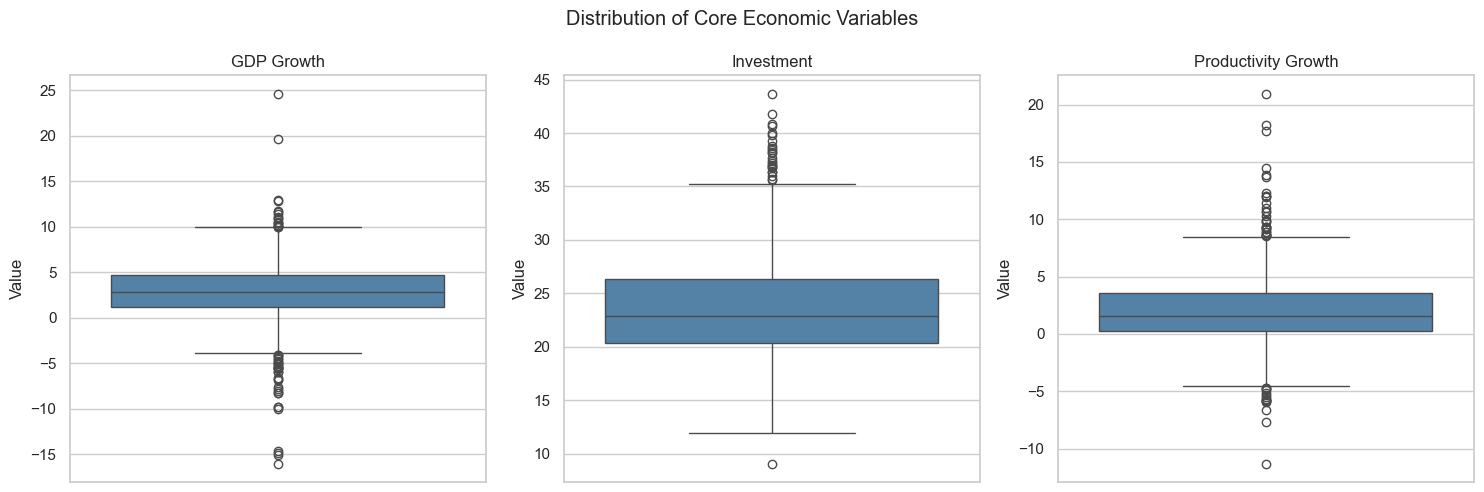

In [82]:
# Draw one box plot for each core variable
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(core_variables),
    figsize=(15, 5)
)

for axis, variable in zip(axes, core_variables):
    sns.boxplot(
        y=core_sample[variable],
        ax=axis,
        color="steelblue"
    )

    axis.set_title(variable)
    axis.set_xlabel("")
    axis.set_ylabel("Value")

plt.suptitle("Distribution of Core Economic Variables")
plt.tight_layout()
plt.show()

## 6. Cleaning decisions

| Issue | Decision | Reason |
|---|---|---|
| Missing core variables | Use complete observations in 2000–2018 | Required for comparable panel estimates |
| Missing education values | Create a separate extended sample | Avoids shrinking the main analysis unnecessarily |
| Extreme values | Retain and flag | Many reflect genuine macroeconomic shocks |
| Imputation | None | Interpolation or mean filling could create artificial economic data |
| Winsorisation | None | Preserves meaningful crisis and recovery observations |
| Identifiers | Standardise and validate | Ensures reliable country–year merges |

In [83]:
# Create an outlier indicator without modifying the original values
outlier_keys = (
    core_outliers[
        ["Country Code", "Year"]
    ]
    .drop_duplicates()
    .assign(Potential_Outlier=True)
)

core_sample = core_sample.merge(
    outlier_keys,
    on=["Country Code", "Year"],
    how="left",
    validate="one_to_one"
)

core_sample["Potential_Outlier"] = (
    core_sample["Potential_Outlier"]
    .fillna(False)
    .astype(bool)
)

print(
    "Country-year observations flagged as potential outliers:",
    core_sample["Potential_Outlier"].sum()
)

print(
    "Country-year observations retained:",
    len(core_sample)
)

Country-year observations flagged as potential outliers: 97
Country-year observations retained: 779


## 7. Final validation

We perform final checks on identifiers, data types, duplicates, missing values, panel dimensions, and sorting before exporting the cleaned datasets.

In [84]:
# Standardise country identifiers
for dataset in [core_sample, extended_sample]:
    dataset["Country Code"] = (
        dataset["Country Code"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    dataset["Country Name"] = (
        dataset["Country Name"]
        .astype(str)
        .str.strip()
    )

    dataset["Year"] = dataset["Year"].astype(int)

# Make the extended sample columns explicit
extended_sample = extended_sample[
    [
        "Country Code",
        "Country Name",
        "Year",
        "GDP Growth",
        "Investment",
        "Education Expenditure",
        "Productivity Growth"
    ]
].copy()

# Arrange the core sample columns
core_sample = core_sample[
    [
        "Country Code",
        "Country Name",
        "Year",
        "GDP Growth",
        "Investment",
        "Productivity Growth",
        "Potential_Outlier"
    ]
].copy()

# Sort both datasets
core_sample = (
    core_sample
    .sort_values(["Country Name", "Year"])
    .reset_index(drop=True)
)

extended_sample = (
    extended_sample
    .sort_values(["Country Name", "Year"])
    .reset_index(drop=True)
)

In [85]:
def validate_cleaned_sample(
    data,
    required_variables,
    expected_observations=None
):
    """
    Report the main structural and data-quality checks.
    """
    duplicate_count = data.duplicated(
        subset=["Country Code", "Year"]
    ).sum()

    infinite_count = np.isinf(
        data[required_variables].to_numpy()
    ).sum()

    missing_count = (
        data[required_variables]
        .isna()
        .sum()
        .sum()
    )

    print("Dimensions:", data.shape)
    print("Countries:", data["Country Code"].nunique())
    print("Period:", data["Year"].min(), "-", data["Year"].max())
    print("Duplicate country-years:", duplicate_count)
    print("Missing required values:", missing_count)
    print("Infinite required values:", infinite_count)
    print(
        "Sorted by country and year:",
        data.equals(
            data.sort_values(
                ["Country Name", "Year"]
            ).reset_index(drop=True)
        )
    )

    if expected_observations is not None:
        print(
            "Expected number of observations:",
            len(data) == expected_observations
        )

In [86]:
print("CORE SAMPLE VALIDATION")
validate_cleaned_sample(
    data=core_sample,
    required_variables=core_variables,
    expected_observations=779
)

print("\nEXTENDED SAMPLE VALIDATION")
validate_cleaned_sample(
    data=extended_sample,
    required_variables=analysis_variables,
    expected_observations=614
)

CORE SAMPLE VALIDATION
Dimensions: (779, 7)
Countries: 41
Period: 2000 - 2018
Duplicate country-years: 0
Missing required values: 0
Infinite required values: 0
Sorted by country and year: True
Expected number of observations: True

EXTENDED SAMPLE VALIDATION
Dimensions: (614, 7)
Countries: 40
Period: 2000 - 2018
Duplicate country-years: 0
Missing required values: 0
Infinite required values: 0
Sorted by country and year: True
Expected number of observations: True


In [87]:
# Number of observations per country
core_panel_structure = (
    core_sample
    .groupby(["Country Code", "Country Name"])
    .agg(
        First_Year=("Year", "min"),
        Last_Year=("Year", "max"),
        Observations=("Year", "size")
    )
    .reset_index()
)

extended_panel_structure = (
    extended_sample
    .groupby(["Country Code", "Country Name"])
    .agg(
        First_Year=("Year", "min"),
        Last_Year=("Year", "max"),
        Observations=("Year", "size")
    )
    .reset_index()
)

print("Core observations per country:")
print(
    core_panel_structure["Observations"].min(),
    "-",
    core_panel_structure["Observations"].max()
)

print("\nExtended observations per country:")
print(
    extended_panel_structure["Observations"].min(),
    "-",
    extended_panel_structure["Observations"].max()
)

display(
    extended_panel_structure
    .sort_values(["Observations", "Country Name"])
    .reset_index(drop=True)
)

Core observations per country:
19 - 19

Extended observations per country:
1 - 19


,Country Code,Country Name,First_Year,Last_Year,Observations
0,MKD,North Macedonia,2002,2002,1
1,FRA,France,2017,2018,2
2,BIH,Bosnia and Herzegovina,2014,2018,5
3,LUX,Luxembourg,2001,2018,6
4,SRB,Serbia,2007,2018,6
5,TUR,Turkiye,2011,2018,8
6,GRC,Greece,2000,2018,9
7,DEU,Germany,2008,2018,10
8,HRV,Croatia,2002,2018,11
9,BEL,Belgium,2005,2018,12


## 8. Export

Two processed CSV files are saved. Downstream notebooks use the core file for the main analysis and the extended file only when discussing education expenditure.

In [88]:
# Define output files
core_output_file = (
    processed_dir / "europe_panel_core_cleaned.csv"
)

extended_output_file = (
    processed_dir / "europe_panel_extended_cleaned.csv"
)

# Export the cleaned samples
core_sample.to_csv(
    core_output_file,
    index=False
)

extended_sample.to_csv(
    extended_output_file,
    index=False
)

print("Core sample saved to:")
print(core_output_file)

print("\nExtended sample saved to:")
print(extended_output_file)

Core sample saved to:
<project-folder>/data/processed/europe_panel_core_cleaned.csv

Extended sample saved to:
<project-folder>/data/processed/europe_panel_extended_cleaned.csv


In [89]:
# Reload the exported files as a final verification
core_check = pd.read_csv(core_output_file)
extended_check = pd.read_csv(extended_output_file)

print("Exported core dimensions:", core_check.shape)
print("Exported extended dimensions:", extended_check.shape)

print("\nFiles exist:")
print("Core:", core_output_file.exists())
print("Extended:", extended_output_file.exists())

display(core_check.head())
display(extended_check.head())

Exported core dimensions: (779, 7)
Exported extended dimensions: (614, 7)

Files exist:
Core: True
Extended: True


,Country Code,Country Name,Year,GDP Growth,Investment,Productivity Growth,Potential_Outlier
0,ALB,Albania,2000,7.463,34.040,6.640,False
1,ALB,Albania,2001,8.864,38.228,8.290,True
2,ALB,Albania,2002,4.628,38.575,4.590,True
3,ALB,Albania,2003,5.333,36.722,4.840,True
4,ALB,Albania,2004,5.266,36.332,4.940,True


,Country Code,Country Name,Year,GDP Growth,Investment,Education Expenditure,Productivity Growth
0,ALB,Albania,2000,7.463,34.040,3.330,6.640
1,ALB,Albania,2001,8.864,38.228,3.342,8.290
2,ALB,Albania,2002,4.628,38.575,3.003,4.590
3,ALB,Albania,2003,5.333,36.722,3.035,4.840
4,ALB,Albania,2004,5.266,36.332,3.131,4.940


## Cleaning summary

The cleaning process produces a complete, balanced core panel without inventing or suppressing economic observations. The main file contains **779 observations for 41 countries from 2000 to 2018**. The education file contains **614 observations for 40 countries** and is explicitly treated as supplementary because its coverage varies across countries and years.